# **Importing Libraries**

In [12]:
# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import regularizers
from tensorflow.keras.applications.efficientnet import preprocess_input

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Extracting Dataset with having 7200 Total Images**

In [26]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path: /kaggle/input/brain-tumor-mri-dataset


In [27]:
IMG_SIZE = 300
BATCH_SIZE = 16
NUM_CLASSES = 4

train_ds = tf.keras.utils.image_dataset_from_directory(
    path + "/Training",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    path + "/Testing",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


# ***ResNet50 Model***

In [28]:
def bottleneck_block(x, filters, stride=1):
    shortcut = x
    f1, f2, f3 = filters

    x = layers.Conv2D(f1, (1, 1), strides=stride, padding='valid', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(f2, (3, 3), strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(f3, (1, 1), strides=1, padding='valid', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != f3:
        shortcut = layers.Conv2D(f3, (1, 1), strides=stride, padding='valid', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x


# ── ResNet-50 with Brain Tumor Config ─────────────────────────────────────────
def resnet50_brain_tumor(input_shape=(224, 224, 3), num_classes=2, freeze_up_to_stage=4):
    inputs = layers.Input(shape=input_shape)

    # Stem
    x = layers.Conv2D(64, (7, 7), strides=2, padding='same', use_bias=False, name='stem_conv')(inputs)
    x = layers.BatchNormalization(name='stem_bn')(x)
    x = layers.ReLU(name='stem_relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same', name='stem_pool')(x)

    # Stage 1 — 56x56x256
    x = bottleneck_block(x, [64, 64, 256], stride=1)
    x = bottleneck_block(x, [64, 64, 256])
    x = bottleneck_block(x, [64, 64, 256])

    # Stage 2 — 28x28x512
    x = bottleneck_block(x, [128, 128, 512], stride=2)
    for _ in range(3):
        x = bottleneck_block(x, [128, 128, 512])

    # Stage 3 — 14x14x1024
    x = bottleneck_block(x, [256, 256, 1024], stride=2)
    for _ in range(5):
        x = bottleneck_block(x, [256, 256, 1024])

    # Stage 4 — 7x7x2048
    x = bottleneck_block(x, [512, 512, 2048], stride=2)
    for _ in range(2):
        x = bottleneck_block(x, [512, 512, 2048])

    x = layers.GlobalAveragePooling2D(name='gap')(x)

    # ── Medical-grade classification head ─────────────────────────────────────
    # Dropout is critical for small medical datasets to prevent overfitting
    x = layers.Dense(512, activation='relu', name='fc1')(x)
    x = layers.BatchNormalization(name='head_bn')(x)
    x = layers.Dropout(0.5, name='dropout1')(x)                  # Heavy dropout
    x = layers.Dense(128, activation='relu', name='fc2')(x)
    x = layers.Dropout(0.3, name='dropout2')(x)

    # Binary output: sigmoid for 2-class, softmax for multi-class
    activation = 'sigmoid' if num_classes == 1 else 'softmax'
    outputs = layers.Dense(num_classes, activation=activation, name='predictions')(x)

    model = models.Model(inputs, outputs)
    
    return model

model = resnet50_brain_tumor(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES)

In [29]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      9,408 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 75, 75,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 75, 75,    │      4,096 │ stem_pool[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_52[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_48 (ReLU)     │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 75, 75,    │     36,864 │ re_lu_48[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_53[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_49 (ReLU)     │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 75, 75,    │     16,384 │ re_lu_49[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 75, 75,    │     16,384 │ stem_pool[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │      1,024 │ conv2d_54[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │      1,024 │ conv2d_55[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_50 (ReLU)     │ (None, 75, 75,    │          0 │ add_16[0][0]    

 Total params: 24,678,468 (94.14 MB)

 Trainable params: 24,624,324 (93.93 MB)

 Non-trainable params: 54,144 (211.50 KB)

In [30]:
# -- Freeze layers for transfer learning -- Freeze layers up to stage 4 (recommended for 5600 training images)
def freeze_model_stages(model, freeze_up_to_stage=4):
    """
    Freeze backbone stages to prevent overfitting on small datasets.

    freeze_up_to_stage options:
      1 → freeze stem only
      2 → freeze stem + stage 1
      3 → freeze stem + stages 1-2
      4 → freeze stem + stages 1-3  ← best for ~5600 images
      5 → freeze everything except head
    """

    # Cumulative block count at end of each stage
    # Stage 1 ends at block 3, Stage 2 at block 7, etc.
    stage_block_counts = {1: 0, 2: 3, 3: 7, 4: 13, 5: 999}
    blocks_to_freeze = stage_block_counts.get(freeze_up_to_stage, 0)

    # Step 1: Unfreeze all layers (clean slate before applying freeze)
    for layer in model.layers:
        layer.trainable = True

    # Step 2: Freeze stem layers (always frozen regardless of stage)
    stem_layer_names = ('stem_conv', 'stem_bn', 'stem_relu', 'stem_pool')
    for layer in model.layers:
        if layer.name in stem_layer_names:
            layer.trainable = False

    # Step 3: Freeze bottleneck blocks up to the chosen stage
    if freeze_up_to_stage >= 2:
        block_idx = 0
        for layer in model.layers:
            # Each bottleneck block contains exactly one Add layer
            # Use it as a block counter
            if isinstance(layer, layers.Add):
                block_idx += 1
            if block_idx <= blocks_to_freeze:
                layer.trainable = False   # freeze this layer

    # Step 4: Force head layers to stay trainable always
    head_layer_names = ('gap', 'fc1', 'head_bn', 'dropout1', 'fc2', 'dropout2', 'predictions')
    for layer in model.layers:
        if layer.name in head_layer_names:
            layer.trainable = True

    # Print summary
    trainable     = sum(tf.size(w).numpy() for w in model.trainable_weights)
    non_trainable = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
    total         = trainable + non_trainable

    print(f"✅ Freezing applied: up to stage {freeze_up_to_stage}")
    print(f"   Trainable params : {trainable:>12,}")
    print(f"   Frozen params    : {non_trainable:>12,}")
    print(f"   Freeze ratio     : {non_trainable / total * 100:.1f}% frozen")

    return model

# Apply freezing
model = freeze_model_stages(model, freeze_up_to_stage=4)

✅ Freezing applied: up to stage 4
   Trainable params :   10,041,476
   Frozen params    :   14,636,992
   Freeze ratio     : 59.3% frozen


In [31]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      9,408 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 75, 75,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 75, 75,    │      4,096 │ stem_pool[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_52[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_48 (ReLU)     │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 75, 75,    │     36,864 │ re_lu_48[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_53[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_49 (ReLU)     │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 75, 75,    │     16,384 │ re_lu_49[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 75, 75,    │     16,384 │ stem_pool[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │      1,024 │ conv2d_54[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │      1,024 │ conv2d_55[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_50 (ReLU)     │ (None, 75, 75,    │          0 │ add_16[0][0]    

 Total params: 24,678,468 (94.14 MB)

 Trainable params: 10,041,476 (38.31 MB)

 Non-trainable params: 14,636,992 (55.84 MB)

In [32]:
# Compute class weights 
import numpy as np

# Extract labels from the dataset (which are categorical)
labels = []
for _, batch_labels in train_ds.unbatch():
    labels.append(np.argmax(batch_labels.numpy()))

class_counts = np.bincount(labels)
total_samples = len(labels)
num_classes   = len(class_counts)

# Formula: weight = total / (num_classes × count)
# → minority class gets higher weight → model penalized more for missing it
class_weights = {
    i: total_samples / (num_classes * count)
    for i, count in enumerate(class_counts)
}

# Print breakdown
# class_names is available from earlier when train_ds was created
class_labels = {i: name for i, name in enumerate(class_names)}
print("📊 Class distribution & weights:")
print(f"   {'Class':<15} {'Images':>8} {'Weight':>8}")
print("   " + "-"*35)
for idx, (count, weight) in enumerate(zip(class_counts, class_weights.values())):
    print(f"   {class_labels[idx]:<15} {count:>8} {weight:>8.3f}")

print(f"\n   ℹ️  Weight > 1.0 means underrepresented → model penalized more")

📊 Class distribution & weights:
   Class             Images   Weight
   -----------------------------------
   glioma              1400    1.000
   meningioma          1400    1.000
   notumor             1400    1.000
   pituitary           1400    1.000

   ℹ️  Weight > 1.0 means underrepresented → model penalized more


In [33]:
# Cell 10: Define training callbacks

callbacks = [

    EarlyStopping(
        monitor             = 'val_loss',
        patience            = 8,  
        restore_best_weights= True,
        verbose             = 1
    ),

    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,        # new_lr = old_lr × 0.5
        patience = 4,
        min_lr   = 1e-7,       # never go below this
        verbose  = 1
    ),

    # Save only the best model checkpoint during training
    ModelCheckpoint(
        filepath        = 'best_brain_tumor_phase1.keras',
        monitor         = 'val_accuracy',
        save_best_only  = True,
        verbose         = 1
    )
]

print("✅ Callbacks defined")
print("   EarlyStopping     : patience=8, monitors val_loss")
print("   ReduceLROnPlateau : patience=4, factor=0.5")
print("   ModelCheckpoint   : saves best val_accuracy model")

✅ Callbacks defined
   EarlyStopping     : patience=8, monitors val_loss
   ReduceLROnPlateau : patience=4, factor=0.5
   ModelCheckpoint   : saves best val_accuracy model


In [25]:
# PHASE 1 — Compile and train with frozen backbone

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),       
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')    
    ]
)

print("🚀 Phase 1: Training classification head...")
print("   Frozen  : stem + stages 1-3")
print("   Trainable: stage 4 + head\n")

history_phase1 = model.fit(
    train_ds,
    epochs          = 15,              
    validation_data = val_ds,
    class_weight    = class_weights,  
    callbacks       = callbacks,
    verbose         = 1
)

🚀 Phase 1: Training classification head...
   Frozen  : stem + stages 1-3
   Trainable: stage 4 + head

Epoch 1/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.5579 - auc: 0.8067 - loss: 1.1521 - precision: 0.6220 - recall: 0.4536
Epoch 1: val_accuracy improved from None to 0.42562, saving model to best_brain_tumor_phase2.keras

Epoch 1: finished saving model to best_brain_tumor_phase2.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 97s 191ms/step - accuracy: 0.6136 - auc: 0.8434 - loss: 1.0226 - precision: 0.6660 - recall: 0.5188 - val_accuracy: 0.4256 - val_auc: 0.6999 - val_loss: 2.1656 - val_precision: 0.4332 - val_recall: 0.3994 - learning_rate: 0.0010
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.7168 - auc: 0.9107 - loss: 0.7483 - precision: 0.7500 - recall: 0.6709
Epoch 2: val_accuracy did not improve from 0.42562
350/350 ━━━━━━━━━━━━━━━━━━━━ 59s 168ms/step - accuracy: 0.7209 - auc: 0.9128 - loss: 0.7316 - precision: 0.7534 - recall: 0.6737 - val_accuracy: 

In [34]:
# PHASE 2 — Unfreeze stage 4, fine-tune with lower LR

block_idx = 0
for layer in model.layers:
    if isinstance(layer, layers.Add):
        block_idx += 1             # count each bottleneck block
    if block_idx > 10:             # unfreeze blocks 11, 12, 13 (stage 4)
        layer.trainable = True

# Verify new trainable param count
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen    = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f"🔓 Stage 4 unfrozen")
print(f"   Trainable params : {trainable:,}")
print(f"   Frozen params    : {frozen:,}\n")

# Recompile with 10x lower LR — fine-tuning needs careful, small updates
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = 'categorical_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Update checkpoint name for phase 2
callbacks[2] = ModelCheckpoint(
    filepath        = 'best_brain_tumor_phase2.keras',
    monitor         = 'val_accuracy',
    save_best_only  = True,
    verbose         = 1
)

print("🚀 Phase 2: Fine-tuning stage 4 + head...")

history_phase2 = model.fit(
    train_ds,
    epochs          = 30,
    validation_data = val_ds,
    class_weight    = class_weights,
    callbacks       = callbacks,
    verbose         = 1
)

🔓 Stage 4 unfrozen
   Trainable params : 18,315,396
   Frozen params    : 6,363,072

🚀 Phase 2: Fine-tuning stage 4 + head...
Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.5891 - auc: 0.8229 - loss: 1.0883 - precision: 0.6374 - recall: 0.5074
Epoch 1: val_accuracy improved from None to 0.54688, saving model to best_brain_tumor_phase2.keras

Epoch 1: finished saving model to best_brain_tumor_phase2.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 135s 323ms/step - accuracy: 0.6559 - auc: 0.8741 - loss: 0.8968 - precision: 0.7048 - recall: 0.5905 - val_accuracy: 0.5469 - val_auc: 0.8075 - val_loss: 1.2513 - val_precision: 0.5711 - val_recall: 0.5119 - learning_rate: 1.0000e-04
Epoch 2/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.7604 - auc: 0.9309 - loss: 0.6440 - precision: 0.7878 - recall: 0.7248
Epoch 2: val_accuracy did not improve from 0.54688
350/350 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.7798 - auc: 0.9402 - loss: 0.5975 - precision: 0.8022 - reca

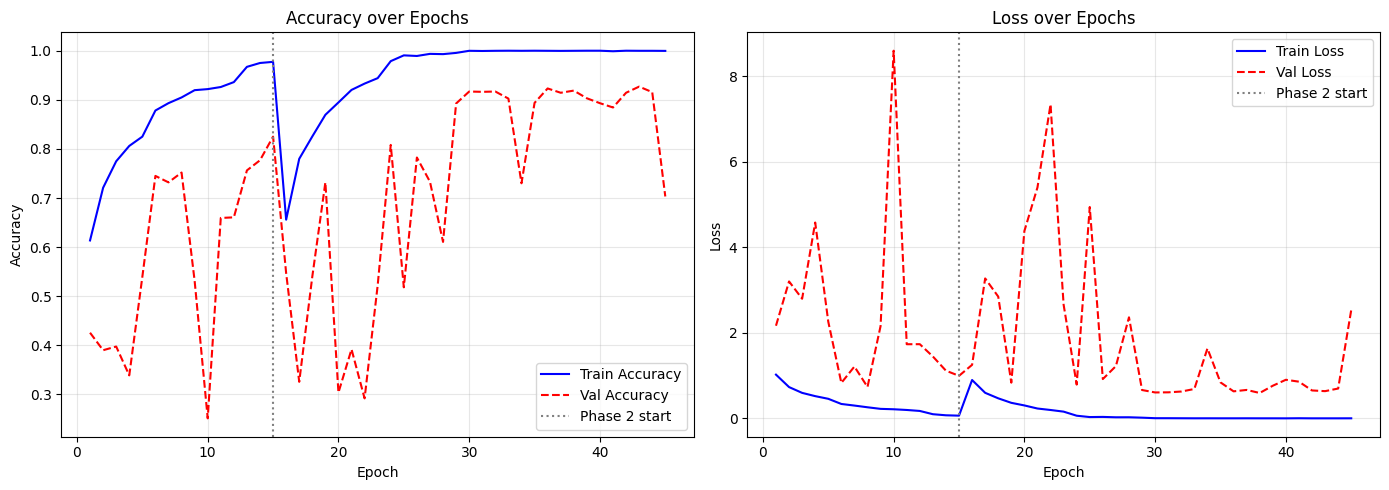

✅ Saved: training_curves.png


In [35]:
# Plot training curves for both phases

def plot_history(h1, h2):
    # Combine both phase histories
    acc     = h1.history['accuracy']     + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss    = h1.history['loss']         + h2.history['loss']
    val_loss= h1.history['val_loss']     + h2.history['val_loss']
    phase_boundary = len(h1.history['accuracy'])   # where phase 1 ends

    epochs = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Accuracy plot ──────────────────────────────────────────────
    axes[0].plot(epochs, acc,     'b-',  label='Train Accuracy')
    axes[0].plot(epochs, val_acc, 'r--', label='Val Accuracy')
    axes[0].axvline(phase_boundary, color='gray', linestyle=':', label='Phase 2 start')
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── Loss plot ──────────────────────────────────────────────────
    axes[1].plot(epochs, loss,     'b-',  label='Train Loss')
    axes[1].plot(epochs, val_loss, 'r--', label='Val Loss')
    axes[1].axvline(phase_boundary, color='gray', linestyle=':', label='Phase 2 start')
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: training_curves.png")

plot_history(history_phase1, history_phase2)

In [38]:
# Evaluate on test set (1600 images)

print("="*55)
print("  FINAL TEST SET EVALUATION")
print("="*55)

results = model.evaluate(val_ds, verbose=1)
metric_names = ['loss', 'accuracy', 'auc', 'precision', 'recall']

print("\n📋 Metrics:")
for name, val in zip(metric_names, results):
    print(f"   {name:<12}: {val:.4f}")

# F1 Score (harmonic mean of precision and recall)
precision = results[metric_names.index('precision')]
recall    = results[metric_names.index('recall')]
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
print(f"   {'F1 Score':<12}: {f1:.4f}")
print(f"\n   ⚠️  Recall (sensitivity) is most critical:")
print(f"       High recall = fewer missed tumors")

  FINAL TEST SET EVALUATION
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.9187 - auc: 0.9666 - loss: 0.5937 - precision: 0.9205 - recall: 0.9187

📋 Metrics:
   loss        : 0.5937
   accuracy    : 0.9187
   auc         : 0.9666
   precision   : 0.9205
   recall      : 0.9187
   F1 Score    : 0.9196

   ⚠️  Recall (sensitivity) is most critical:
       High recall = fewer missed tumors


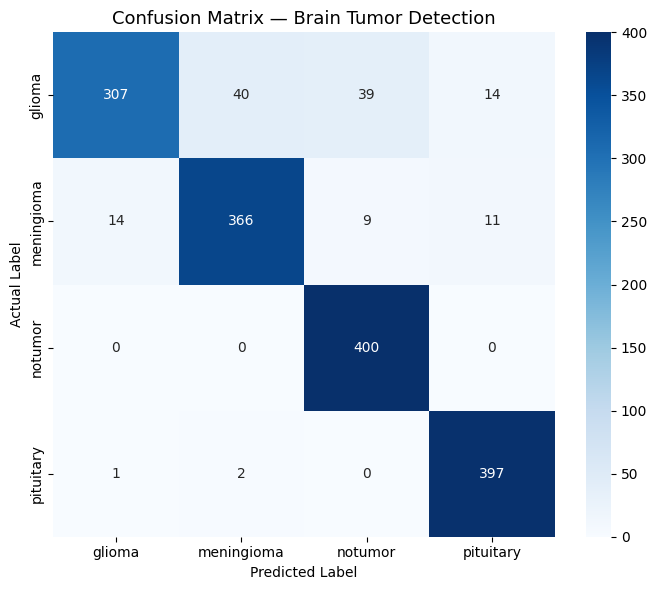


📋 Classification Report:
              precision    recall  f1-score   support

      glioma       0.95      0.77      0.85       400
  meningioma       0.90      0.92      0.91       400
     notumor       0.89      1.00      0.94       400
   pituitary       0.94      0.99      0.97       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600

   Note: Matrix is multi-class, avoiding binary stat printout above.


In [ ]:
# Confusion matrix + classification report
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Extract ground truth and predictions from the validation dataset mapping
true_classes = []
preds = []

for images, labels_batch in val_ds:
    # Get ground truth
    true_classes.extend(np.argmax(labels_batch.numpy(), axis=1))
    # Get predictions
    batch_preds = model.predict(images, verbose=0)
    preds.extend(batch_preds)

preds = np.array(preds)
pred_classes = np.argmax(preds, axis=1)        # predicted class index
true_classes = np.array(true_classes)          # ground truth class index

# class_names was defined earlier when the dataset was loaded
class_labels = class_names

# ── Confusion Matrix ───────────────────────────────────────────────
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = class_labels,
    yticklabels = class_labels
)
plt.title('Confusion Matrix — Brain Tumor Detection', fontsize=13)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Classification Report ──────────────────────────────────────────
print("\n📋 Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# ── Key stats ──────────────────────────────────────────────────────
# Note: ravel() returning 4 values assumes a binary classification.
# Since we have 4 classes, we need to adapt this, or avoid specific binary terminology.
if len(class_labels) == 2:
    tn, fp, fn, tp = cm.ravel()
    print(f"   True Positives  (tumor correctly detected) : {tp}")
    print(f"   False Negatives (tumor missed — dangerous) : {fn}")
    print(f"   True Negatives  (healthy correctly cleared): {tn}")
    print(f"   False Positives (false alarm)              : {fp}")
else:
    print("   Note: Matrix is multi-class, avoiding binary stat printout above.")

In [42]:
# Save the final model to Google Drive so it persists after Colab session ends
model.save("/content/drive/MyDrive/brain_tumor_model_ResNet50.keras")
print("Model saved!")

Model saved!


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf

model = tf.keras.models.load_model("/content/drive/MyDrive/brain_tumor_model_ResNet50.keras")
print("Model loaded!")
model.summary()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      9,408 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 75, 75,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 75, 75,    │      4,096 │ stem_pool[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_52[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_48 (ReLU)     │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 75, 75,    │     36,864 │ re_lu_48[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_53[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_49 (ReLU)     │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 75, 75,    │     16,384 │ re_lu_49[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 75, 75,    │     16,384 │ stem_pool[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │      1,024 │ conv2d_54[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │      1,024 │ conv2d_55[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_50 (ReLU)     │ (None, 75, 75,    │          0 │ add_16[0][0]    

 Total params: 61,309,262 (233.88 MB)

 Trainable params: 18,315,396 (69.87 MB)

 Non-trainable params: 6,363,072 (24.27 MB)

 Optimizer params: 36,630,794 (139.74 MB)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
True Label : notumor
Image Path : /kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-no_259.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Predicted Class: notumor


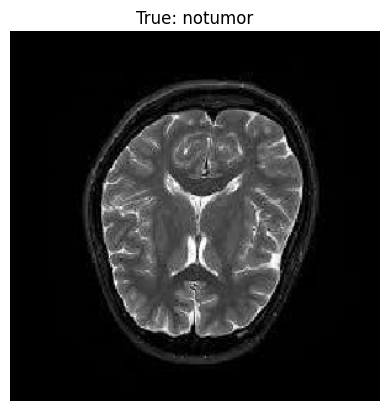

In [3]:
import random
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub
import numpy as np

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

# Load the trained model
model = tf.keras.models.load_model("/content/drive/MyDrive/brain_tumor_model.keras")

# Define class names, as they were determined during dataset loading
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(300, 300))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create a batch

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    predicted_class = class_names[np.argmax(score)]
    print(f"Predicted Class: {predicted_class}")

# Pick a random class, then a random image from that class
test_dir = path + "/Testing"

random_class = random.choice(os.listdir(test_dir))
random_image = random.choice(os.listdir(os.path.join(test_dir, random_class)))
img_path = os.path.join(test_dir, random_class, random_image)

print(f"True Label : {random_class}")
print(f"Image Path : {img_path}")

# Predict
predict_image(img_path)

# Show the image
img = tf.keras.utils.load_img(img_path, target_size=(300, 300))
plt.imshow(img)
plt.title(f"True: {random_class}")
plt.axis('off')
plt.show()